ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing


**Name: Jana Alamer, ID: 2230002669, Section: 8FA1**


In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [20]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [21]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("laptopData.csv")
df.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5.0,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8.0,Asus,Ultrabook,14,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9.0,Acer,Ultrabook,14,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Ram` should be numeric, not text.
- `Weight` should be numeric, not text.
- `Inches` should be numeric

In [22]:
df.dtypes

,0
Unnamed: 0,float64
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object


We observe that some numerical features are stored as object type. Ram contains "GB", Weight contains "kg", and Inches is stored as text. These incorrect data types should be converted before applying preprocessing techniques.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Ram` from text (e.g., "8GB") to numeric.
- `Weight` from text (e.g., "1.37kg") to numeric.
- `Inches` to numeric format.
- `Remove` the unnecessary column (Unnamed: 0).

In [23]:
# Remove unnecessary index column
df = df.drop('Unnamed: 0', axis=1, errors='ignore')

# Convert Ram from "8GB" to numeric
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')

# Convert Weight from "1.37kg" to numeric
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Convert Inches to numeric
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')

df.dtypes

,0
Company,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,float64
Memory,object
Gpu,object
OpSys,object
Weight,float64


`Ram`, `Weight`, and `Inches` were successfully converted to numeric data types. The unnecessary column (`Unnamed: 0`) was removed because it only represents row indices and does not provide useful information for analysis.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [24]:
df.isna().sum()

,0
Company,30
TypeName,30
Inches,31
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30
Weight,31


In [25]:
print(df.shape)

print(df.isna().sum().sum())

display(df[df.isna().any(axis=1)].head())

(1303, 11)
332


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The output shows the number of missing values in each column.

We observe that several columns contain missing values. Most columns have 30 missing values, while Inches and Weight have 31 missing values.

These missing values should be handled before proceeding with further analysis to ensure data quality and reliable results.

### 3.2 Handle Missing Values

### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [26]:
df = df.dropna()

print(df.shape)

df.isna().sum()

(1271, 11)


,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0
Weight,0


Strategy Used: **Remove Records** ( *dropna* )

A total of 332 missing values were detected in the dataset. The dataset originally contained 1303 rows, and the missing values were mainly concentrated in approximately 30 completely empty records.

These incomplete records represent only about 2.3% of the dataset, which is a relatively small proportion. Since the affected rows contained little or no useful information, removing them was considered more appropriate than estimating or imputing values.

Therefore, the Remove Records strategy ( *dropna* ) was selected. After removing the incomplete records, the dataset contained no remaining missing values and was ready for further analysis.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

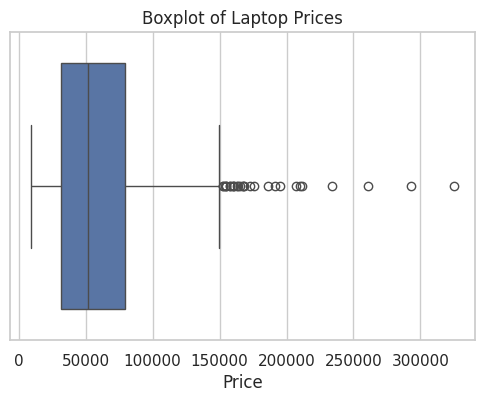

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title('Boxplot of Laptop Prices')
plt.show()

Points outside the whiskers represent potential outliers. The boxplot shows several laptops with unusually high prices compared to the majority of the dataset. These extreme values may influence statistical analysis and machine learning models.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [28]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]

outliers.head(15)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16.0,512GB SSD,AMD Radeon Pro 560,macOS,1.83,152274.2400
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32.0,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,324954.7200
204,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16.0,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.80,162770.4000
238,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32.0,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.70,207259.2000
247,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16.0,256GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.60,159786.7200
297,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16.0,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42,153705.3408
517,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,24.0,512GB SSD,Nvidia GeForce GTX1080,Windows 10,2.24,158135.0400
530,Dell,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16.0,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42,160520.3856
563,Lenovo,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8.0,256GB SSD,Nvidia Quadro M620M,Windows 10,3.40,159786.7200
610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32.0,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.50,261018.7200


The output displays laptops identified as potential outliers based on the IQR method. These laptops have unusually high prices compared to the majority of the dataset. While some may represent premium devices, they can still influence statistical analysis and machine learning models.

### Remove Outliers
We remove values outside the acceptable range.

In [29]:
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (1271, 11)
After removing outliers: (1243, 11)


The outliers detected in the Price column were removed using the IQR method. The number of rows decreased from 1271 to 1243, meaning that only 28 extreme observations were removed. Since these outliers represent a small proportion of the dataset, removing them helps reduce the influence of unusually high laptop prices and improves data quality for further analysis.

The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

The following numerical features will be normalized:

- `Price`
- `Ram`
- `Inches`
- `Weight`

Both Min-Max Normalization and Z-score Standardization will be applied.

In [30]:
df[['Price','Ram','Inches','Weight']].head()

,Price,Ram,Inches,Weight
0,71378.6832,8.0,13.3,1.37
1,47895.5232,8.0,13.3,1.34
2,30636.0000,8.0,15.6,1.86
3,135195.3360,16.0,15.4,1.83
4,96095.8080,8.0,13.3,1.37


In [31]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[['Price','Ram','Inches','Weight']] = minmax_scaler.fit_transform(
    df[['Price','Ram','Inches','Weight']]
)

df_minmax[['Price','Ram','Inches','Weight']].head()

,Price,Ram,Inches,Weight
0,0.196741,0.111111,0.125490,0.123408
1,0.122353,0.111111,0.125490,0.120705
2,0.067679,0.111111,0.215686,0.167553
3,0.398895,0.238095,0.207843,0.164850
4,0.275038,0.111111,0.125490,0.123408


After applying Min-Max normalization, all selected numerical features were scaled to a range between 0 and 1.

The smallest value in each feature becomes 0 and the largest becomes 1, while the relative differences between laptops are preserved.

This ensures that Price, Ram, Inches, and Weight contribute equally to the analysis and prevents features with larger numerical values from dominating the results.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['Price', 'Ram', 'Inches', 'Weight']].copy()

df_standardized[['Price', 'Ram', 'Inches', 'Weight']] = scaler.fit_transform(
    df_standardized[['Price', 'Ram', 'Inches', 'Weight']]
)

df_standardized.head()

,Price,Ram,Inches,Weight
0,0.308094,-0.083250,-0.937811,-0.876310
1,-0.321574,-0.083250,-0.937811,-0.913449
2,-0.784364,-0.083250,0.239406,-0.269698
3,2.019248,1.353902,0.137039,-0.306837
4,0.970849,-0.083250,-0.937811,-0.876310


After applying Z-score standardization, the numerical features (Price, Ram, Inches, and Weight) were transformed to have a mean close to 0 and a standard deviation close to 1.

Values above the original mean appear as positive values, while values below the mean appear as negative values. This can be observed in the output where some laptop features have positive standardized scores and others have negative scores.

Unlike Min-Max normalization, Z-score standardization is not limited to the range between 0 and 1. This method is particularly useful before applying PCA because it ensures that all features contribute equally regardless of their original scales.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

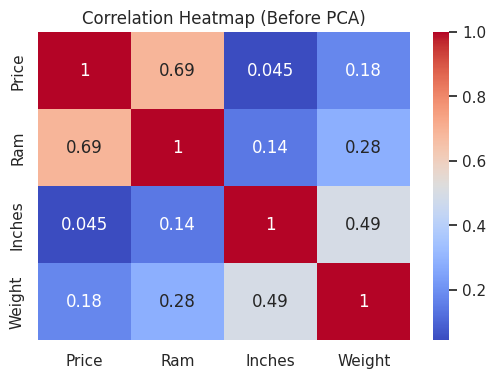

In [33]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df_standardized[['Price', 'Ram', 'Inches', 'Weight']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features (`Price`, `Ram`, `Inches`, and `Weight`).

The strongest correlation is between `Price` and `Ram` (0.69), indicating that laptops with higher `RAM` tend to have higher `prices`. A moderate correlation is also observed between `Inches` and `Weight` (0.49), suggesting that larger laptops are generally heavier.

Other feature pairs show weak correlations, meaning they contribute different information about the laptops.

Since some features are moderately correlated, PCA can help reduce dimensionality by combining overlapping information into fewer components while preserving most of the dataset's variance.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [34]:
from sklearn.decomposition import PCA

X = df_standardized[['Price', 'Ram', 'Inches', 'Weight']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.48475455 0.31722918]


The `Explained Variance Ratio` shows how much information is retained by each principal component.

In this dataset, PC1 explains approximately 48.5% of the variance, while PC2 explains approximately 31.7%.

Together, the first two principal components retain about 80.2% of the total variance, meaning that most of the important information in the original features is preserved after dimensionality reduction.

This indicates that PCA is effective in reducing the dataset dimensions while keeping the majority of the data variability.

In [35]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot.
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
# plt.xlabel("Amount (Standardized)")
# plt.ylabel("Boxes Shipped (Standardized)")
# plt.title("Scatter Plot: Amount vs Boxes Shipped")
# plt.show()

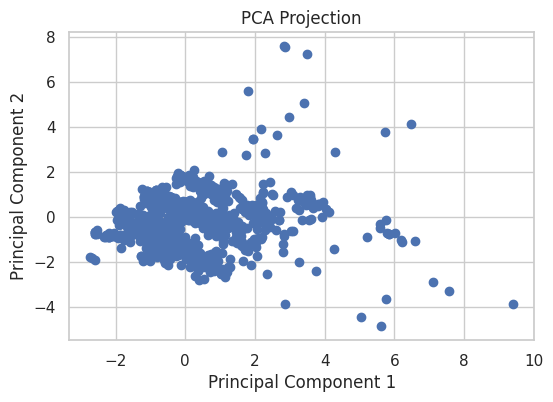

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one laptop in the dataset.

The axes no longer represent the original features (Price, Ram, Inches, and Weight). Instead:

The horizontal axis represents Principal Component 1 (PC1).
The vertical axis represents Principal Component 2 (PC2).

Most laptops are clustered near the center of the plot, while a smaller number of observations appear farther away, indicating greater variation in those devices.

PCA successfully reduced the four numerical features into two principal components while preserving approximately 80.2% of the total variance.

This projection provides a simplified representation of the dataset while retaining most of its important information.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset. ✅

- **Task 2**
Apply one missing value strategy and explain why. ✅

- **Task 3**
Detect and handle outliers using IQR. ✅

- **Task 4**
Normalize numerical features using both Min-Max and Z-score. ✅
- **Task 5**
Apply PCA and interpret explained variance. ✅


End of Assignment 2